In [56]:
import pickle
import pandas as pd
import re
from collections import defaultdict, Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os


In [69]:
with open("/workspace/CCE_NLI/code/Abstractions/final_abstractions.pkl", 'rb') as f:
    abs_map = pickle.load(f)

In [70]:
len(abs_map)

144

In [32]:
def get_indiv_concepts(formula) -> set:
    concepts = set()
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.add(c[:end_idx])
    return concepts

def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw=[]
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
        raw.extend(concepts)
    
    return unit_concepts, set(raw)

def build_binary_mask(neuron_mask, foundational_concept_list) -> torch.Tensor:
    num_neurons = len(neuron_mask)
    num_concepts = len(foundational_concept_list)

    # Step 1: Initialize tensor
    tensor = torch.zeros((num_neurons, num_concepts), dtype=torch.float32)

    # Step 2: Fill in ones
    for i, concepts in enumerate(neuron_mask.values()):
        for j, concept in enumerate(foundational_concept_list):
            if concept in concepts:
                tensor[i, j] = 1.0

    # Step 3: Compute row sums
    row_sums = tensor.sum(dim=1, keepdim=True)

    # Step 4: Normalize safely
    dist_tensor = torch.zeros_like(tensor)
    row_mask = (row_sums != 0).squeeze(1)  # True for rows with sum > 0
    dist_tensor[row_mask] = tensor[row_mask] #/ row_sums[row_mask]

    return dist_tensor



def get_neurons_for_cps(concepts, mapping):
    neurons = []
    for neuron, cps in mapping.items():
        for c in cps:
            if c in concepts:
                neurons.append(neuron)
                break
    return neurons

def get_all_cps_for_pi(folder):
    root_path = Path(folder)

    # Find all matching CSV files
    csv_pattern = 'Cluster*IOUS1024N.csv'
    csv_files = list(root_path.rglob(csv_pattern))
    
    concept_dict=defaultdict(lambda: defaultdict(set))
    s=set()
    for csv_file in csv_files:
        concepts = []
        csv_file = os.path.join(folder, csv_file)
        df = pd.read_csv(csv_file)
        for unit, formula in zip(df.unit, df.best_name):
            concept_dict[csv_file.split("/")[-2]][csv_file.split("/")[-1]].update(get_indiv_concepts(formula))
        
     
        for u, c in concept_dict.items():
            s.update(c)
    return concept_dict, s


In [102]:


def find_cluster(raw_concept):
    for cluster in abs_map:
        if raw_concept in abs_map[cluster]:
            return cluster
def find_abstractions(expls):
    glob = set([i for j in expls.values() for i in j ])
    abstracts=[]
    for concept in glob:
        raw_concept = concept.split(":")[-1]
        abstraction_cluster = find_cluster(raw_concept)
        #if abstraction_cluster==143: continue
        abstracts.append(abstraction_cluster)
    return Counter(abstracts), set(abstracts)


In [185]:
all_models_all_methods_ious=defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
validruns=[]
model='BERT'
methods=['CoFi','lottery_ticket']
for method in methods:
    valid_runs=0
    for fname in range(5,8):
        try:
            cluster_to_concepts, set_all_concepts = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/{method}/Run0.25_{fname}/Expls/')
            if not cluster_to_concepts:
                break
            if fname==5:
                dense = cluster_to_concepts['0.0%Pruned']
                freq_dense, dense_abs=find_abstractions(dense)
            start=1
            for sparsity in cluster_to_concepts:
                if sparsity == '0.0%Pruned': continue
                
                sparse = cluster_to_concepts[sparsity]
                frequency, sparse_abs = find_abstractions(sparse)
                iou=len(sparse_abs&dense_abs)/len(dense_abs|sparse_abs)
                
                all_models_all_methods_ious[model][method][start]+=iou
                start+=1
            valid_runs+=1
            
        except Exception as e:
            print(e)
 
    validruns.append(valid_runs)
pi={0:0.0, 1:25.0, 2:43.75, 3:57.81, 4:68.36, 5:76.27, 5:82.03}
for mod, method_ in all_models_all_methods_ious.items():
    r=0
    for m, sparsity in method_.items():
        for s,iou in sparsity.items():
            all_models_all_methods_ious[mod][m][s]  /= validruns[r]     
        r+=1
#rename x axis 
for mod, method_ in all_models_all_methods_ious.items():
    for m, sparsity in method_.items():
        for s in list(sparsity.keys()):  # list() creates a copy so looping over old version
            all_models_all_methods_ious[mod][m][pi[s]] = sparsity.pop(s)


In [186]:
all_models_all_methods_ious


defaultdict(<function __main__.<lambda>()>,
            {'BERT': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'CoFi': defaultdict(int,
                                      {25.0: 0.8702204228520019,
                                       43.75: 0.8614692653673164,
                                       57.81: 0.8422470180838784,
                                       68.36: 0.8596383224317046,
                                       82.03: 0.8601449275362318}),
                          'lottery_ticket': defaultdict(int,
                                      {25.0: 0.8539474246730073,
                                       43.75: 0.8415535818020937,
                                       57.81: 0.8450756949332021,
                                       68.36: 0.8308783283428314,
                                       82.03: 0.8252038510659201})})})

AttributeError: module 'matplotlib.pyplot' has no attribute 'x_labels'

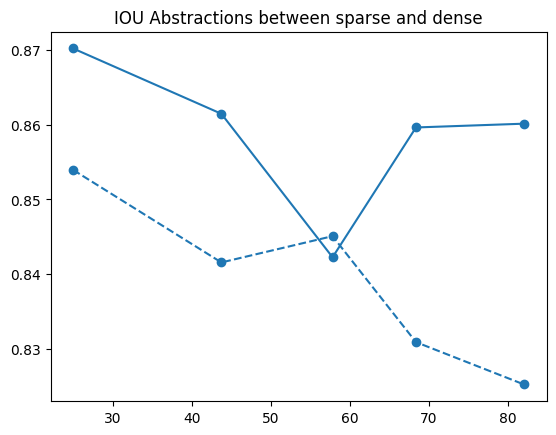

In [189]:
colors = plt.cm.tab10.colors
linestyles = ['-', '--', ':']

model_colors = {model: colors[i] for i, model in enumerate(all_models_all_methods_ious.keys())}

plt.figure()

for model, methods in all_models_all_methods_ious.items():
    for j, (method, vals) in enumerate(methods.items()):
        sparsity = [float(k) for k in vals.keys()]
        scores = list(vals.values())
        sparsity, scores = zip(*sorted(zip(sparsity, scores)))

        plt.plot(
            sparsity,
            scores,
            marker='o',
            color=model_colors[model],
            linestyle=linestyles[j],
            label=f"{model} - {method}"
        )
plt.title('IOU Abstractions between sparse and dense')
plt.xlabels("Sparsity (%)")
plt.y_label("IOU")
plt.legend(ncol=3)
plt.show()
